In [19]:
from langgraph.graph import StateGraph, END, START
from typing import TypedDict, Annotated
from langchain.tools import tool
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages
import os
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun

import requests

In [10]:
load_dotenv()

True

In [11]:
STOCK_API_KEY = os.getenv('stock_api')

In [3]:
GROQ_API_KEY = os.getenv('GROQ_API_KEY')

model = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

In [5]:
search_tool = DuckDuckGoSearchRun()

@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """
    Perform a basic arithmetic operation on two numbers.
    Supported operations : add, mul, div, sub
    """

    try:
        if operation == 'add':
            result = first_num + second_num
        elif operation == 'sub':
            result = first_num - second_num
        elif operation == 'mul':
            result = first_num * second_num
        elif operation == 'div':
            if second_num == 0:
                return {'error' : 'Division by zero is not allowed'}
            result = first_num / second_num
        else:
            return {"error" : f'Unsupported operation "{operation}" \n choose from below \n add, sub, mul, div'}
        return {
            'first_num': first_num,
            'second_num': second_num,
            'operation' : operation,
            'result': result
        }
    except Exception as e:
        return {'error' : str(e)}

In [13]:
@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for given symbol (e.g. 'AAPL', 'TSLA')
    using Alpha Vantage with API Key in URL
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey={STOCK_API_KEY}"
    r = requests.get(url)
    return r.json()

In [14]:
tools = [search_tool, get_stock_price, calculator]
model_with_tools = model.bind_tools(tools)

In [16]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [21]:
def chat_node(state: ChatState):
    """
    LLM node that may answer or request the tool call
    """
    messages = state['messages']
    response = model_with_tools.invoke(messages)
    return {'messages': response}

tool_node = ToolNode(tools)

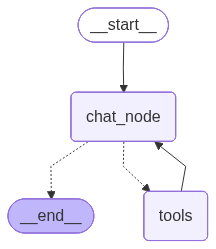

In [ ]:
graph = StateGraph(ChatState)

graph.add_node("chat_node", chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node", tools_condition)
graph.add_edge("tools", "chat_node")

chatbot = graph.compile()

chatbot

In [24]:
out = chatbot.invoke({"messages": [HumanMessage(content="Hello!")]})

In [25]:
out

{'messages': [HumanMessage(content='Hello!', additional_kwargs={}, response_metadata={}, id='17b2da70-5fdb-4028-aa21-db32b1dc4c30'),
  AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "Hello!". We should respond politely. No need for tools.'}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 239, 'total_tokens': 274, 'completion_time': 0.078268999, 'completion_tokens_details': {'reasoning_tokens': 17}, 'prompt_time': 0.010002804, 'prompt_tokens_details': None, 'queue_time': 0.045096256, 'total_time': 0.088271803}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e10890e4b9', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c6508-5637-7b50-8204-42f415010621-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 239, 'output_tokens': 35, 'total_tokens': 274, 'output_token_details': {'reasoning': 17}})]}

In [26]:
out = chatbot.invoke({'messages': [HumanMessage(content="divide 22 by 7")]})

out

{'messages': [HumanMessage(content='divide 22 by 7', additional_kwargs={}, response_metadata={}, id='9ac6b141-3341-4337-85c4-68c7c8f47cb5'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants to divide 22 by 7. Use calculator function.', 'tool_calls': [{'id': 'fc_2efcd6c1-a6fc-44b2-90c5-2e886cfc38f1', 'function': {'arguments': '{"first_num":22,"operation":"div","second_num":7}', 'name': 'calculator'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 243, 'total_tokens': 301, 'completion_time': 0.12520105, 'completion_tokens_details': {'reasoning_tokens': 15}, 'prompt_time': 0.011603337, 'prompt_tokens_details': None, 'queue_time': 0.045881502, 'total_time': 0.136804387}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e10890e4b9', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c6509-6f20-70b1-81f8-2a1143ec7888-0', tool_calls

In [27]:
out = chatbot.invoke({'messages' : [HumanMessage(content="What is current stock price of Microsoft")]})
out

{'messages': [HumanMessage(content='What is current stock price of Microsoft', additional_kwargs={}, response_metadata={}, id='3a8fbd82-a486-4754-b780-ce290a1b9bf5'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to get current stock price of Microsoft, ticker MSFT. Use get_stock_price function.', 'tool_calls': [{'id': 'fc_3a12c75e-e750-47ab-88bf-c3a4a9020602', 'function': {'arguments': '{"symbol":"MSFT"}', 'name': 'get_stock_price'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 244, 'total_tokens': 294, 'completion_time': 0.107921482, 'completion_tokens_details': {'reasoning_tokens': 21}, 'prompt_time': 0.089154498, 'prompt_tokens_details': None, 'queue_time': 0.078720492, 'total_time': 0.19707598}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_626f3fc5e0', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c650a-9a72-7

In [28]:
out = chatbot.invoke({"messages": [HumanMessage(content="who won yesterday's t20 match?")]})
out

Impersonate 'edge_101' does not exist, using 'random'


{'messages': [HumanMessage(content="who won yesterday's t20 match?", additional_kwargs={}, response_metadata={}, id='6c3f5d11-f110-479e-8ea5-7081b2b9be20'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "who won yesterday\'s t20 match?" Need to identify which T20 match? Could be cricket. Need to know date: today is 2026-02-16, so yesterday is 2026-02-15. Need to find which T20 match happened on that date. Could be many matches worldwide. Likely they refer to a notable match, maybe an international T20? Could be a specific tournament. We need to search. Use duckduckgo search query: "T20 match February 15 2026 result".', 'tool_calls': [{'id': 'fc_28576ed0-e836-4fa0-847d-07ed47585119', 'function': {'arguments': '{"query":"T20 match February 15 2026 result"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 154, 'prompt_tokens': 245, 'total_tokens': 399, 'completion_time': 0.331489712, 'completio

In [29]:
out = chatbot.invoke({'messages' : [HumanMessage(content="what is distance between susner and Indore, can you multiply it with 2 to get overall travel distance?")]})

In [30]:
out

{'messages': [HumanMessage(content='what is distance between susner and Indore, can you multiply it with 2 to get overall travel distance?', additional_kwargs={}, response_metadata={}, id='f5ae9d39-0fd5-439a-9691-0b8ab959791f'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks: distance between Susner and Indore, then multiply by 2 for overall travel distance (presumably round trip). Need distance. Likely need to search. Use duckduckgo search.', 'tool_calls': [{'id': 'fc_ba7509db-dfe0-4882-bc50-92185863056b', 'function': {'arguments': '{"query":"distance between Susner and Indore"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 78, 'prompt_tokens': 260, 'total_tokens': 338, 'completion_time': 0.169164565, 'completion_tokens_details': {'reasoning_tokens': 42}, 'prompt_time': 0.067108972, 'prompt_tokens_details': None, 'queue_time': 0.054107617, 'total_time': 0.236273537}, 'model_name': 'openai/gpt-